# Importing Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

2025-12-18 12:12:14.563478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766059934.730027      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766059934.780814      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# Data Preparation

In [4]:
from pathlib import Path

base_path = Path("/kaggle/input/eye-diseases-classification/dataset")
print("Contents:", os.listdir(base_path))


# Get all image paths
images_paths = list(base_path.glob("*/*.jpg"))

# Extract labels from parent folder names
labels = [p.parent.name for p in images_paths]


Contents: ['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']


In [5]:
df = pd.DataFrame({
    "Image Path": [str(p) for p in images_paths],
    "Label": labels
})

df


,Image Path,Label
0,/kaggle/input/eye-diseases-classification/data...,glaucoma
1,/kaggle/input/eye-diseases-classification/data...,glaucoma
2,/kaggle/input/eye-diseases-classification/data...,glaucoma
3,/kaggle/input/eye-diseases-classification/data...,glaucoma
4,/kaggle/input/eye-diseases-classification/data...,glaucoma
...,...,...
2913,/kaggle/input/eye-diseases-classification/data...,cataract
2914,/kaggle/input/eye-diseases-classification/data...,cataract
2915,/kaggle/input/eye-diseases-classification/data...,cataract
2916,/kaggle/input/eye-diseases-classification/data...,cataract


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image Path  2918 non-null   object
 1   Label       2918 non-null   object
dtypes: object(2)
memory usage: 45.7+ KB


# Splitting Data To Train,Test & Validation

In [7]:
train_df , temp_df = train_test_split(df,test_size=0.3,random_state=42,stratify=df["Label"])
test_df , Valid_df = train_test_split(temp_df,test_size=0.5,stratify=temp_df["Label"])

In [8]:
print("Train Shape : ",train_df.shape)
print("Test Shape : ",test_df.shape)
print("Validation Shape ",Valid_df.shape)

Train Shape :  (2042, 2)
Test Shape :  (438, 2)
Validation Shape  (438, 2)


In [9]:
print("Train Classes : ",train_df.Label.value_counts())
print("Test Classes : ",test_df.Label.value_counts())
print("Validation Classes ",Valid_df.Label.value_counts())

Train Classes :  Label
normal      752
cataract    656
glaucoma    634
Name: count, dtype: int64
Test Classes :  Label
normal      161
cataract    141
glaucoma    136
Name: count, dtype: int64
Validation Classes  Label
normal      161
cataract    141
glaucoma    136
Name: count, dtype: int64


# Data Augmentation

In [10]:
IMG_SIZE = (224, 224)

# Training generator with augmentation
gen_tr = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    shear_range=0.2,
    rescale=1./255   # normalize pixel values
)

train_gen = gen_tr.flow_from_dataframe(
    train_df,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,   # ✅ fixed
    shuffle=True,
    seed=4
)

# Validation and test generators (no augmentation, only rescaling)
gen = ImageDataGenerator(rescale=1./255)

test_gen = gen.flow_from_dataframe(
    test_df,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=8,    # ✅ fixed
    shuffle=False
)

valid_gen = gen.flow_from_dataframe(
    Valid_df,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=8,    # ✅ fixed
    shuffle=False
)


Found 2042 validated image filenames belonging to 3 classes.
Found 438 validated image filenames belonging to 3 classes.
Found 438 validated image filenames belonging to 3 classes.


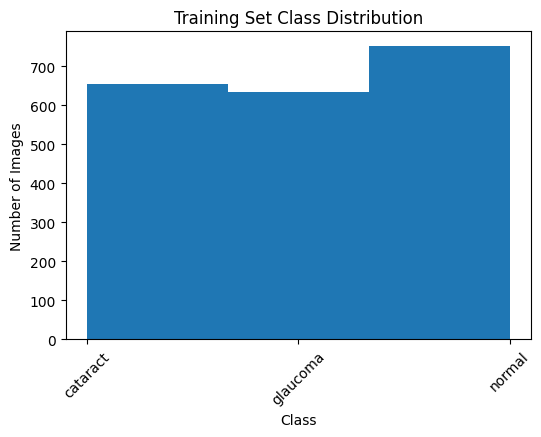

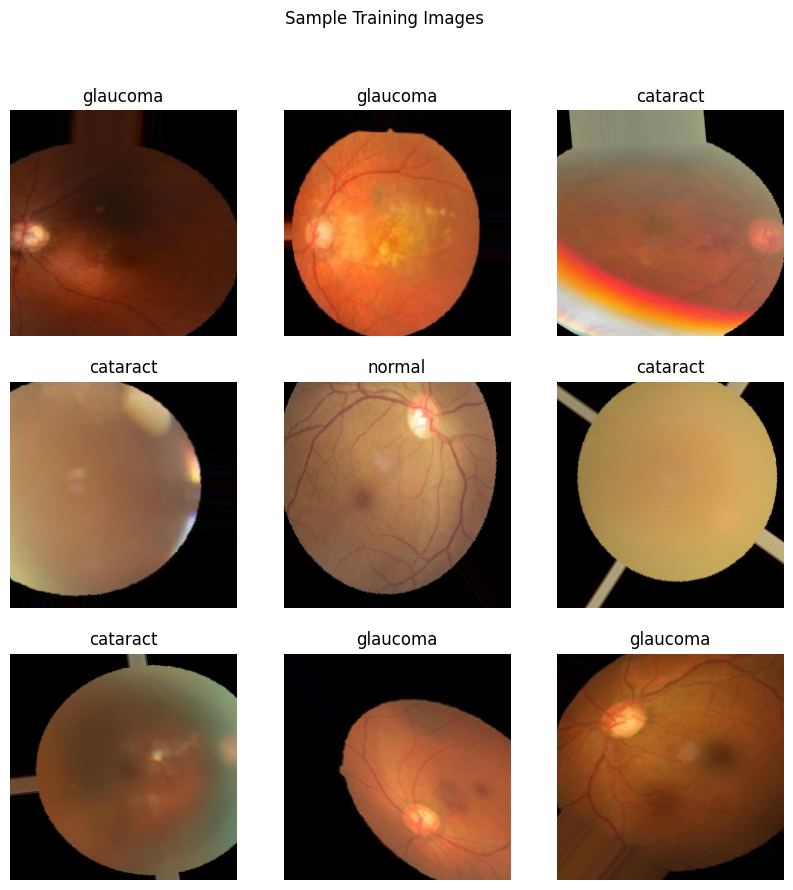

In [11]:
# Get class names from generator
class_names = list(train_gen.class_indices.keys())

# Class distribution
plt.figure(figsize=(6,4))
plt.hist(train_gen.classes, bins=len(class_names))
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Sample images
x_batch, y_batch = next(train_gen)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(class_names[y_batch[i].argmax()])
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.show()


# CNN Training

In [12]:
num_classes = len(train_gen.class_indices)

model = models.Sequential([
    layers.Input(shape=(224,224,3)),   # modern way
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')   # fixed
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


I0000 00:00:1766059955.513824      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# -------------------------------
# 4. Train model
# -------------------------------
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1766059959.914530     113 service.cc:148] XLA service 0x7b3e1c007040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766059959.915355     113 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766059960.208409     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/64 ━━━━━━━━━━━━━━━━━━━━ 6:14 6s/step - accuracy: 0.2500 - loss: 1.1225

I0000 00:00:1766059963.743804     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 577ms/step - accuracy: 0.3273 - loss: 1.3744 - val_accuracy: 0.3676 - val_loss: 1.0921
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 381ms/step - accuracy: 0.3768 - loss: 1.0905 - val_accuracy: 0.3699 - val_loss: 1.0872
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 389ms/step - accuracy: 0.3819 - loss: 1.0886 - val_accuracy: 0.4178 - val_loss: 1.0742
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 390ms/step - accuracy: 0.4097 - loss: 1.0731 - val_accuracy: 0.4338 - val_loss: 1.0924
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.4109 - loss: 1.0685 - val_accuracy: 0.5753 - val_loss: 0.9865


In [17]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 382ms/step - accuracy: 0.7968 - loss: 0.5084 - val_accuracy: 0.7648 - val_loss: 0.5817
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 384ms/step - accuracy: 0.7999 - loss: 0.5025 - val_accuracy: 0.7511 - val_loss: 0.6396
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 379ms/step - accuracy: 0.7828 - loss: 0.5301 - val_accuracy: 0.7603 - val_loss: 0.5647
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.8171 - loss: 0.4624 - val_accuracy: 0.7648 - val_loss: 0.5752
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 385ms/step - accuracy: 0.8288 - loss: 0.4439 - val_accuracy: 0.7648 - val_loss: 0.5851
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 415ms/step - accuracy: 0.7948 - loss: 0.4829 - val_accuracy: 0.7352 - val_loss: 0.6043
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 384ms/step - accuracy: 0.8024 - loss: 0.4748 - val_accuracy: 0.7763 - val_loss: 0.5146
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.8018 - loss: 0.4673 - val_accu

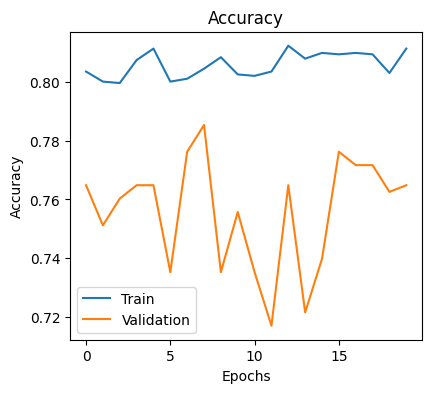

In [18]:
# -------------------------------
# 5. Plot training curves
# -------------------------------
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

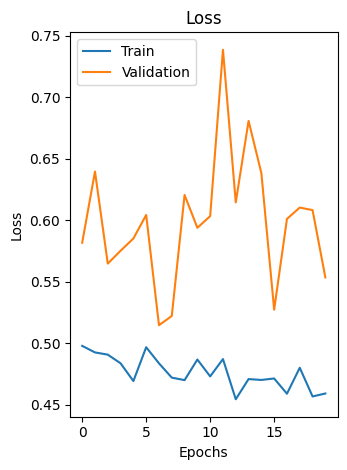

In [19]:
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [20]:
# -------------------------------
# 6. Evaluate on test set
# -------------------------------
loss, acc = model.evaluate(test_gen)
print("Test accuracy:", acc)

55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8211 - loss: 0.4558
Test accuracy: 0.8127853870391846


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


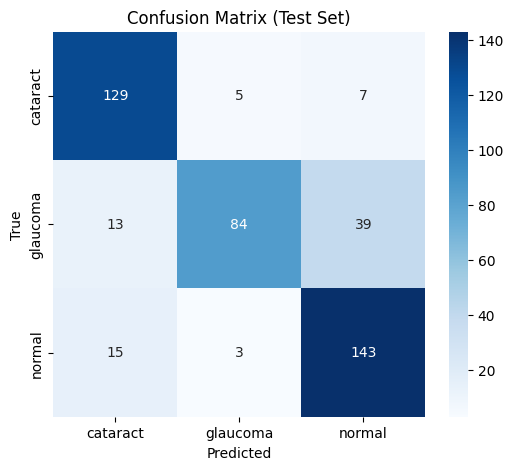

              precision    recall  f1-score   support

    cataract       0.82      0.91      0.87       141
    glaucoma       0.91      0.62      0.74       136
      normal       0.76      0.89      0.82       161

    accuracy                           0.81       438
   macro avg       0.83      0.81      0.81       438
weighted avg       0.83      0.81      0.81       438



In [21]:
# -------------------------------
# 7. Confusion Matrix
# -------------------------------
y_true = test_gen.classes
y_pred = model.predict(test_gen)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print(classification_report(y_true, y_pred_labels, target_names=class_names))

# Using a Pre-Trained Model

### EfficientNetB0

In [22]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


# Clearing the previous model from memory to avoid conflicts
tf.keras.backend.clear_session()

# Load EfficientNetB0 without the top classifier
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model initially
base_model.trainable = False

# Build model
num_classes = len(train_gen.class_indices)

model_eff = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model_eff.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

model_eff.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,101,382 (15.65 MB)

 Trainable params: 51,811 (202.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
def plot_history(history, model_name="Model"):
    """
    Plots training & validation accuracy and loss curves.
    
    Args:
        history: Keras History object returned by model.fit()
        model_name: Name of the model (string) for titles
    """
    # Accuracy
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()


In [24]:
base_model.trainable = True
model_eff.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])


Epoch 1/10
55/64 ━━━━━━━━━━━━━━━━━━━━ 3s 395ms/step - accuracy: 0.4522 - loss: 1.0658

E0000 00:00:1766062475.265291     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766062475.451884     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766062475.917734     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766062476.126461     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766062476.488154     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.4621 - loss: 1.0577 - val_accuracy: 0.3196 - val_loss: 1.0985
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 424ms/step - accuracy: 0.6850 - loss: 0.7855 - val_accuracy: 0.3219 - val_loss: 1.1050
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 399ms/step - accuracy: 0.8125 - loss: 0.5685 - val_accuracy: 0.3219 - val_loss: 1.3005
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 401ms/step - accuracy: 0.8422 - loss: 0.4328 - val_accuracy: 0.3219 - val_loss: 1.2549
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 401ms/step - accuracy: 0.8472 - loss: 0.4327 - val_accuracy: 0.3219 - val_loss: 1.1087
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 418ms/step - accuracy: 0.8688 - loss: 0.3950 - val_accuracy: 0.3219 - val_loss: 1.3998
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.8623 - loss: 0.3980 - val_accuracy: 0.5274 - val_loss: 1.1180
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.8829 - loss: 0.3396 - val_accuracy: 0.5457 

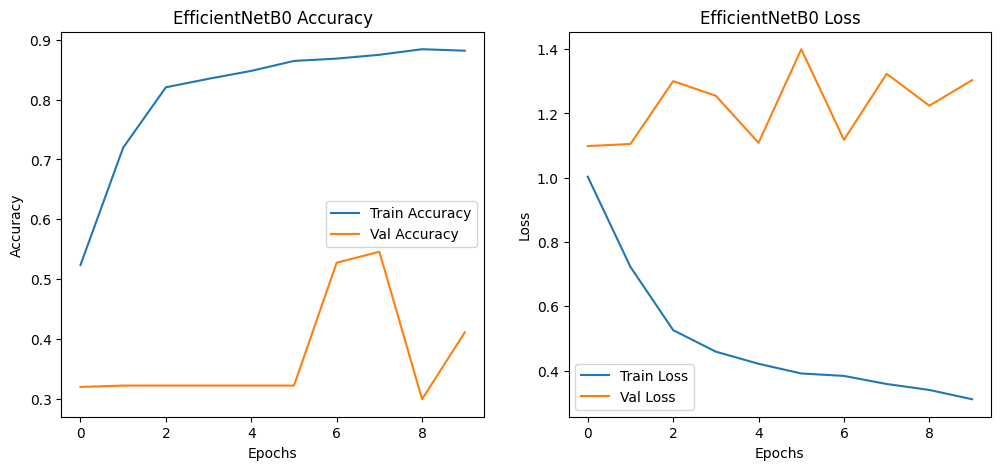

In [26]:
from tensorflow.keras.optimizers import Adam

model_eff.compile( optimizer=Adam(learning_rate=1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"] )

history_eff = model_eff.fit(train_gen, validation_data=valid_gen, epochs=10)
plot_history(history_eff, model_name="EfficientNetB0")

### Resnet50

In [27]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

#Clearing the previous model from memory to avoid conflicts
tf.keras.backend.clear_session()

# Load ResNet50 without the top classifier
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model initially
base_model.trainable = False

# Build model
num_classes = len(train_gen.class_indices)

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model_resnet.compile(optimizer="adam",
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])

model_resnet.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
base_model.trainable = True
model_eff.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 113s 888ms/step - accuracy: 0.5748 - loss: 1.1581 - val_accuracy: 0.3676 - val_loss: 8455.4424
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 437ms/step - accuracy: 0.7268 - loss: 0.7044 - val_accuracy: 0.3219 - val_loss: 1.8280
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 425ms/step - accuracy: 0.8081 - loss: 0.5282 - val_accuracy: 0.3219 - val_loss: 10.9983
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 409ms/step - accuracy: 0.8137 - loss: 0.5334 - val_accuracy: 0.3219 - val_loss: 21.6021
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 414ms/step - accuracy: 0.8171 - loss: 0.5177 - val_accuracy: 0.3219 - val_loss: 8.9056
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 429ms/step - accuracy: 0.8500 - loss: 0.4284 - val_accuracy: 0.3219 - val_loss: 5.5448
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 418ms/step - accuracy: 0.8449 - loss: 0.4272 - val_accuracy: 0.3219 - val_loss: 6.3859
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 429ms/step - accuracy: 0.8585 - loss: 0.3945 - va

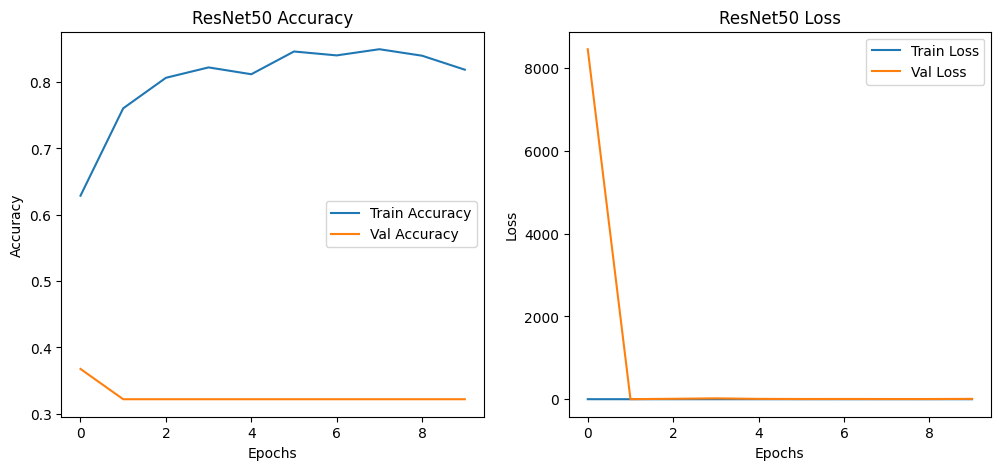

In [29]:
# ResNet50
history_resnet = model_resnet.fit(train_gen, validation_data=valid_gen, epochs=10)
plot_history(history_resnet, model_name="ResNet50")

### MobileNetV2

In [30]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers

num_classes = len(train_gen.class_indices)

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False   # Phase 1: freeze

model_mobilenet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model_mobilenet.compile(optimizer="adam",
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])

model_mobilenet.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
# MobileNetV2
history_mobilenetv2 = model_mobilenet.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 543ms/step - accuracy: 0.5728 - loss: 1.0259 - val_accuracy: 0.7534 - val_loss: 0.5885
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 417ms/step - accuracy: 0.7723 - loss: 0.5806 - val_accuracy: 0.7648 - val_loss: 0.5717
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 424ms/step - accuracy: 0.7743 - loss: 0.5690 - val_accuracy: 0.7443 - val_loss: 0.6852
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step - accuracy: 0.7865 - loss: 0.5464 - val_accuracy: 0.7763 - val_loss: 0.5672
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 388ms/step - accuracy: 0.7983 - loss: 0.5003 - val_accuracy: 0.7648 - val_loss: 0.6558
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.7890 - loss: 0.5135 - val_accuracy: 0.7443 - val_loss: 0.6715
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 389ms/step - accuracy: 0.8071 - loss: 0.5137 - val_accuracy: 0.7466 - val_loss: 0.6372
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 381ms/step - accuracy: 0.8177 - loss: 0.5024 - val_accu

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.8193 - loss: 0.4663 - val_accuracy: 0.7831 - val_loss: 0.5540
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.8207 - loss: 0.4615 - val_accuracy: 0.7694 - val_loss: 0.5809
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 395ms/step - accuracy: 0.8159 - loss: 0.4640 - val_accuracy: 0.7854 - val_loss: 0.5331
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 388ms/step - accuracy: 0.8250 - loss: 0.4755 - val_accuracy: 0.7808 - val_loss: 0.5469
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 386ms/step - accuracy: 0.7916 - loss: 0.5249 - val_accuracy: 0.7808 - val_loss: 0.5523
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.8112 - loss: 0.4702 - val_accuracy: 0.7922 - val_loss: 0.5847
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 384ms/step - accuracy: 0.8184 - loss: 0.4651 - val_accuracy: 0.7945 - val_loss: 0.5525
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 418ms/step - accuracy: 0.8277 - loss: 0.4448 - val_accu

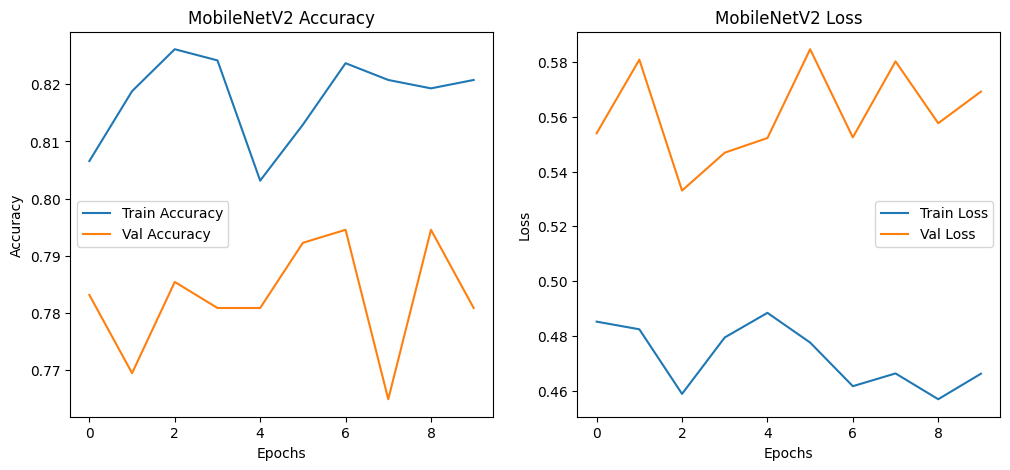

In [32]:
base_model.trainable = True
model_eff.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
# MobileNetV2
history_mobilenetv2 = model_mobilenet.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10
)

plot_history(history_mobilenetv2, model_name="MobileNetV2")
